# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [26]:
STUDENT_NAME = "Phan Hoài Bảo Khang"  # TODO: Họ và tên
STUDENT_ID = "2045240120"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Phan Hoài Bảo Khang (2045240120)


In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\admin\Documents\GitHub\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [28]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [29]:
# TODO N1
row_max = logits.max(axis=1, keepdims=True)
shifted_logits = logits - row_max
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = class_probabilities[np.arange(logits.shape[0]), predicted_classes]

In [30]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [31]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [32]:
# TODO N2
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [33]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [34]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [35]:
# TODO N3
correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)
review_mask = ~(correct_mask & high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [36]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [37]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**
1. Mỗi dòng đại diện cho đối tượng gì? Mỗi dòng đại diện cho thông số kỹ thuật, mức độ rủi ro bảo hiểm và giá cả của một mẫu xe ô tô cụ thể (thuộc thế hệ xe nhập khẩu năm 1985).  
2. Ký hiệu missing value trong CSV là gì? Dấu hỏi chấm (?).  
3. symboling có ý nghĩa gì? Là chỉ số đánh giá mức độ rủi ro bảo hiểm đi kèm với xe, nhận giá trị từ -3 (an toàn nhất) đến 3 (rủi ro cao nhất). 
<!-- Viết câu trả lời tại đây. -->

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [38]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [39]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [40]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**
- Không nên điền tất cả các cột numeric bằng cùng một giá trị vì mỗi cột mang ý nghĩa vật lý và thang đo khác nhau (ví dụ: không thể điền giá trị thiếu của horsepower bằng giá trị trung bình của price). Làm vậy sẽ làm méo mó nghiêm trọng phân phối của các đặc trưng.
- Với biến mục tiêu price, lựa chọn drop (loại bỏ dòng thiếu) phù hợp hơn vì mục tiêu EDA chủ yếu xoay quanh việc phân tích các yếu tố ảnh hưởng trực tiếp đến giá xe; việc điền giá trị giả lập (như mean/median) cho nhãn mục tiêu sẽ tạo ra các thông tin nhiễu cho các phân tích tương quan sau này.
- Cột normalized_losses bị thiếu tới 41 dữ liệu (khoảng 20%). Điều này làm giảm độ tin cậy khi sử dụng thuộc tính này làm biến dự đoán độc lập, đòi hỏi phải cẩn trọng áp dụng kỹ thuật điền phù hợp (như median theo cụm nhóm hãng xe) nếu không muốn loại bỏ quá nhiều dữ liệu của hàng. 
<!-- Viết 3--6 câu tại đây. -->

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [41]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [42]:
# TODO D3
analysis_df = df_clean.dropna(subset=AUTO_FEATURES)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [43]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = X_auto[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [44]:
# TODO D5
engine_index = AUTO_FEATURES.index('engine_size')
engine_price_corr = np.corrcoef(X_auto[:, engine_index], X_auto[:, price_index])[0, 1]
price_by_body_style = analysis_df.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

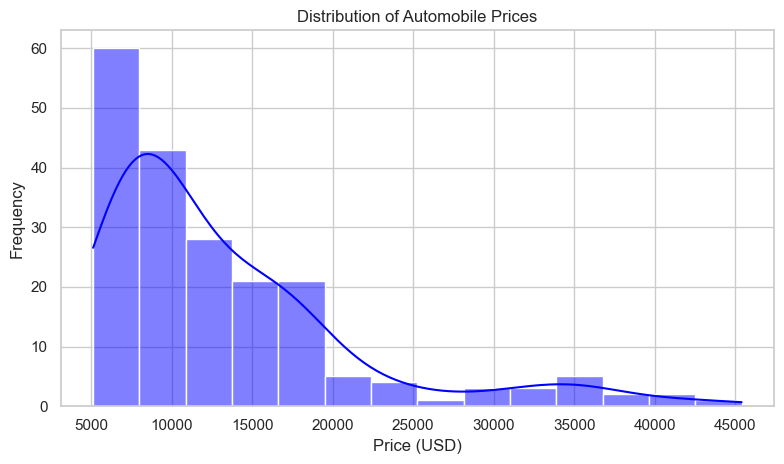

In [45]:
# TODO M2.1: histogram/KDE của price
sns.histplot(analysis_df['price'], kde=True, color='blue')
plt.title('Distribution of Automobile Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Nhận xét:** Phân phối giá xe (price) bị lệch phải (positive skew) một cách rõ rệt. Phần lớn các mẫu xe tập trung ở phân khúc giá rẻ đến tầm trung từ 5,000 USD đến 15,000 USD, và có một số ít dòng xe cao cấp kéo dài đồ thị về phía bên phải với mức giá trên 35,000 USD.<!-- 1--2 câu -->

## M2.2 Dataset có cân bằng theo body style không?

C:\Users\admin\AppData\Local\Temp\ipykernel_29940\752943380.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=analysis_df, x='body_style', order=analysis_df['body_style'].value_counts().index, palette='viridis')


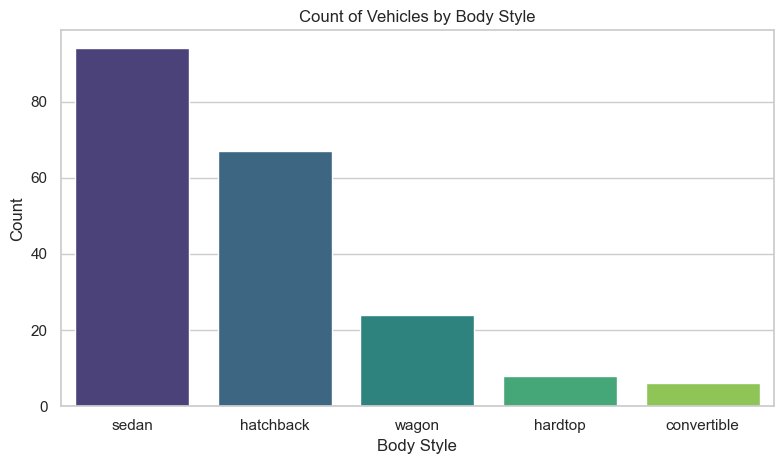

In [46]:
# TODO M2.2: countplot của body_style
sns.countplot(data=analysis_df, x='body_style', order=analysis_df['body_style'].value_counts().index, palette='viridis')
plt.title('Count of Vehicles by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Nhận xét:** Dataset không cân bằng theo kiểu thân xe (body_style). Sedan và Hatchback chiếm số lượng áp đảo toàn bộ dữ liệu, trong khi các kiểu xe thể thao hoặc mui trần như Hardtop và Convertible chỉ xuất hiện rất ít với tần suất thấp.<!-- 1--2 câu -->

## M2.3 Price khác nhau theo body style ra sao?

C:\Users\admin\AppData\Local\Temp\ipykernel_29940\3443254167.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='body_style', y='price', palette='Set2')


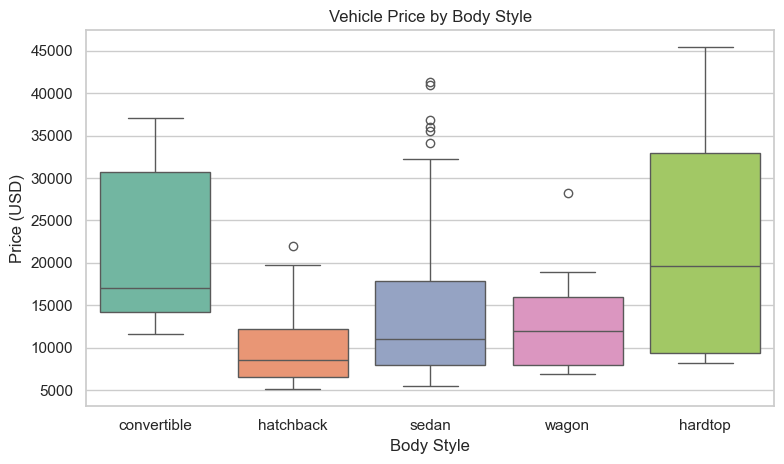

In [47]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=analysis_df, x='body_style', y='price', palette='Set2')
plt.title('Vehicle Price by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

**Nhận xét:** Các kiểu xe ít phổ biến hơn như Hardtop và Convertible có mức giá trung vị lớn và phân tán rộng ở phân khúc cao. Ngược lại, dòng Hatchback có mức giá thấp và đồng đều nhất, còn Sedan xuất hiện nhiều outlier phân khúc đắt tiền.<!-- 1--2 câu -->

## M2.4 Engine size liên quan thế nào tới price?

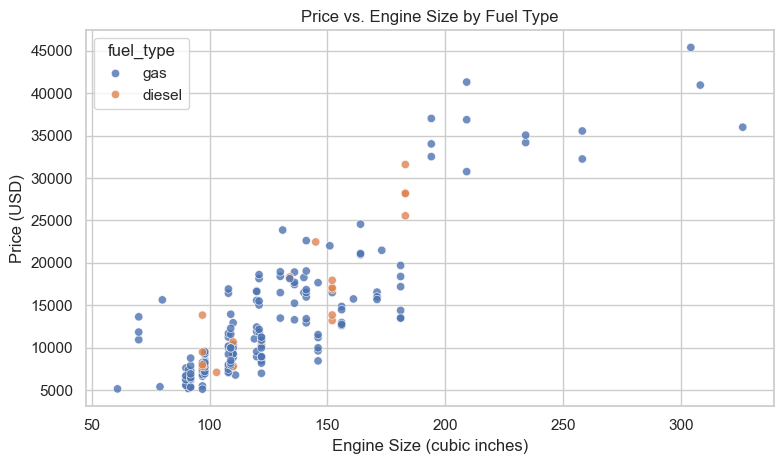

In [48]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data=analysis_df, x='engine_size', y='price', hue='fuel_type', alpha=0.8)
plt.title('Price vs. Engine Size by Fuel Type')
plt.xlabel('Engine Size (cubic inches)')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

**Nhận xét:** Có mối quan hệ tuyến tính đồng biến rất mạnh giữa kích thước động cơ (engine_size) và giá xe (price). Động cơ lớn hơn tỷ lệ thuận với giá thành đắt hơn; bên cạnh đó xe chạy động cơ diesel chủ yếu tập trung ở phân khúc động cơ tầm trung.<!-- 1--2 câu -->

## M2.5 Các feature numeric tương quan ra sao?

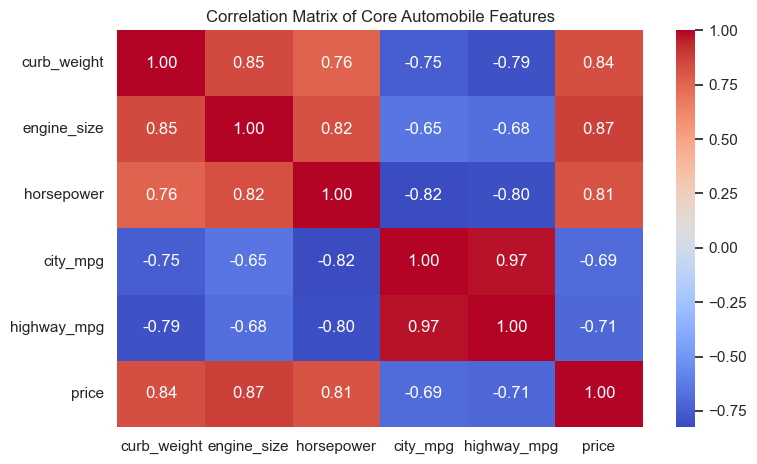

In [49]:
# TODO M2.5: correlation heatmap
sns.heatmap(analysis_df[AUTO_FEATURES].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Core Automobile Features')
plt.tight_layout()
plt.show()

**Nhận xét:** 
Các tính năng curb_weight, engine_size, và horsepower có mối tương quan thuận cực kỳ mạnh với price (đều > 0.8). Ngược lại, chúng tương quan nghịch rất mạnh với khả năng tiết kiệm nhiên liệu city_mpg và highway_mpg (khoảng -0.7 đến -0.8).<!-- 1--2 câu -->

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

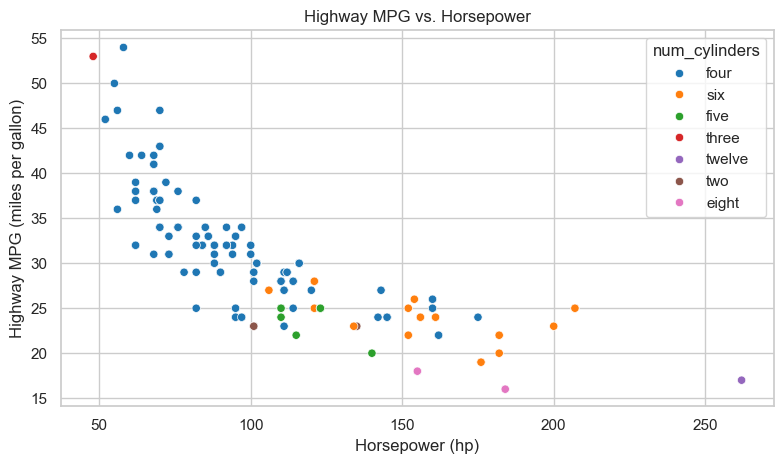

In [50]:
# TODO M2.6: biểu đồ tự chọn
sns.scatterplot(data=analysis_df, x='horsepower', y='highway_mpg', hue='num_cylinders', palette='tab10')
plt.title('Highway MPG vs. Horsepower')
plt.xlabel('Horsepower (hp)')
plt.ylabel('Highway MPG (miles per gallon)')
plt.tight_layout()
plt.show()

**Nhận xét:** Tồn tại mối quan hệ nghịch biến phi tuyến tính rõ ràng giữa công suất và hiệu suất nhiên liệu. Xe có horsepower càng cao thì highway_mpg càng thấp (tốn xăng hơn), và các dòng xe có số xi-lanh lớn (6, 8, 12) nằm hoàn toàn ở vùng công suất cao và tốn nhiên liệu này.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

Qua phân tích khám phá dữ liệu (EDA) trên bộ dữ liệu ô tô năm 1985, ta rút ra một số phát hiện cốt lõi như sau: Thứ nhất, giá xe chịu ảnh hưởng lớn nhất từ cấu trúc kích thước vật lý và hiệu năng sức mạnh động cơ, minh chứng bằng hệ số tương quan rất cao giữa price với engine_size (0.87) và curb_weight (0.84). Thứ hai, có một sự đánh đổi rõ ràng giữa hiệu năng xe và môi trường: các xe mạnh mẽ, đắt tiền có mối quan hệ nghịch biến mạnh với chỉ số tiết kiệm nhiên liệu (tương quan khoảng -0.7). Thứ ba, các phân khúc kiểu xe cao cấp và hiếm (Convertible, Hardtop) giữ giá trị bán ra cao hơn đáng kể so với dòng phổ thông Sedan hay Hatchback.

Tuy nhiên, bộ dữ liệu tồn tại một số hạn chế: kích thước mẫu khá nhỏ (chỉ 205 mẫu trước khi làm sạch), gây khó khăn khi phân tích các nhóm thiểu số như động cơ 12 xi-lanh hoặc xe mui trần. Cột normalized_losses bị khuyết thiếu quá nhiều (20%), làm giảm giá trị sử dụng.

Một ví dụ điển hình về correlation không đồng nghĩa với causation (tương quan không phải nhân quả) là mối quan hệ giữa trọng lượng xe curb_weight và price (0.84). Xe nặng hơn không trực tiếp làm cho giá xe tăng lên bằng cách tăng khối lượng sắt thép, mà bởi vì xe đắt tiền thường có kích thước lớn hơn, được trang bị nhiều động cơ phức tạp hơn, nội thất cao cấp và các tính năng an toàn dày đặc hơn khiến trọng lượng tăng lên.